# Segmentation RFM — Online Retail II

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))

from src.load_data import charger_ventes_en_ligne
from src.clean_transactions import nettoyer_transactions
from src.rfm import segmenter_clients

donnees = charger_ventes_en_ligne()
donnees = nettoyer_transactions(donnees)

rfm = segmenter_clients(donnees)
rfm.head()

,customer_id,last_purchase,frequency,monetary,recency,r_score,f_score,m_score,segment
0,12346.0,2011-01-18 10:01:00,12,77556.46,326,2,5,5,Clients fidèles
1,12347.0,2011-12-07 15:52:00,8,5633.32,2,5,4,5,Champions
2,12348.0,2011-09-25 13:13:00,5,2019.40,75,3,4,4,Clients fidèles
3,12349.0,2011-11-21 09:51:00,4,4428.69,19,5,3,5,Gros acheteurs
4,12350.0,2011-02-02 16:01:00,1,334.40,310,2,1,2,Clients réguliers


## Répartition des clients par segment

In [2]:
repartition_segments = rfm["segment"].value_counts()
repartition_segments

segment
Clients réguliers    2052
Champions            1482
Perdus                880
Clients fidèles       870
À risque              455
Nouveaux clients       75
Gros acheteurs         67
Name: count, dtype: int64

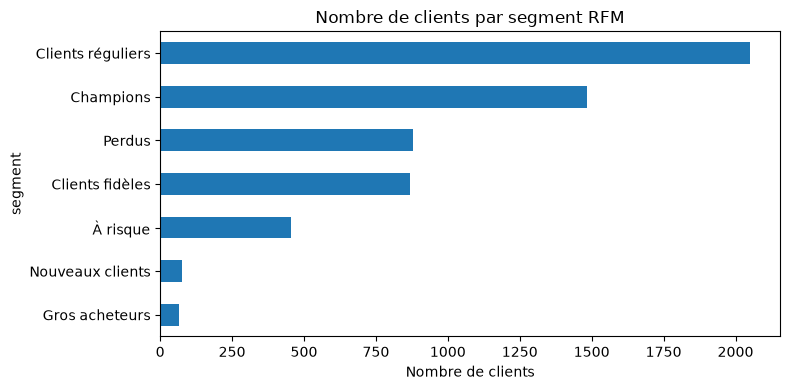

In [3]:
plt.figure(figsize=(8, 4))
repartition_segments.sort_values().plot(kind="barh")
plt.title("Nombre de clients par segment RFM")
plt.xlabel("Nombre de clients")
plt.tight_layout()
plt.show()

## Revenu total par segment

In [4]:
revenu_par_segment = (
    rfm.groupby("segment")["monetary"]
    .sum()
    .sort_values(ascending=False)
)
revenu_par_segment

segment
Champions            1.229314e+07
Clients fidèles      2.849447e+06
Clients réguliers    1.278619e+06
Gros acheteurs       5.976616e+05
À risque             3.938215e+05
Perdus               3.084027e+05
Nouveaux clients     2.233831e+04
Name: monetary, dtype: float64

## Nombre de commandes moyen et valeur moyenne par segment

In [5]:
rfm.groupby("segment").agg(
    frequence_moyenne=("frequency", "mean"),
    montant_moyen=("monetary", "mean"),
    recence_moyenne=("recency", "mean"),
    nb_clients=("customer_id", "nunique"),
).sort_values("montant_moyen", ascending=False)

,frequence_moyenne,montant_moyen,recence_moyenne,nb_clients
segment,,,,
Gros acheteurs,2.850746,8920.322552,216.223881,67
Champions,15.659244,8294.965354,20.367072,1482
Clients fidèles,8.140230,3275.226962,203.025287,870
À risque,2.958242,865.541736,387.547253,455
Clients réguliers,1.958090,623.108632,143.270468,2052
Perdus,1.200000,350.457661,559.430682,880
Nouveaux clients,1.000000,297.844133,11.280000,75


## Clients "Champions" (à fidéliser en priorité)

In [6]:
rfm[rfm["segment"] == "Champions"].sort_values("monetary", ascending=False).head(10)[
    ["customer_id", "recency", "frequency", "monetary"]
]

,customer_id,recency,frequency,monetary
5695,18102.0,1,145,608821.65
2279,14646.0,2,152,528602.52
1791,14156.0,10,156,313946.37
2541,14911.0,1,398,295972.63
5053,17450.0,8,51,246973.09
1332,13694.0,4,143,196482.81
5112,17511.0,3,60,175603.55
4298,16684.0,4,55,147142.77
68,12415.0,24,28,144458.37
2688,15061.0,4,127,137818.52


## Clients "À risque" (bons clients devenus inactifs)

In [7]:
rfm[rfm["segment"] == "À risque"].sort_values("monetary", ascending=False).head(10)[
    ["customer_id", "recency", "frequency", "monetary"]
]

,customer_id,recency,frequency,monetary
1142,13501.0,288,3,2885.11
458,12806.0,435,4,2878.96
3441,15817.0,421,3,2766.40
377,12725.0,371,4,2694.56
2064,14431.0,303,4,2614.20
800,13151.0,296,3,2580.74
4408,16795.0,365,3,2492.39
2848,15221.0,366,4,2465.45
385,12733.0,234,4,2424.87
3568,15946.0,503,3,2304.18


## Export

In [8]:
rfm.to_csv(Path("../data/processed/customers_rfm.csv"), index=False)
print("Fichier exporté : data/processed/customers_rfm.csv")

Fichier exporté : data/processed/customers_rfm.csv
